In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("spam.csv")
df.sample(3)

,Category,Message
3815,ham,Can. Dunno wat to get 4 her...
2444,ham,&lt;#&gt; great loxahatchee xmas tree burning...
1030,ham,"Its good, we'll find a way"


In [3]:
df["Category"].value_counts()

Category
ham     4825
spam     747
Name: count, dtype: int64

In [4]:
X = df[["Message"]]
y = df["Category"]

In [5]:
!python -m pip install imblearn

Defaulting to user installation because normal site-packages is not writeable

   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ---------------------------------------- 3/3 [imblearn]



In [7]:
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler(random_state = 42)
X_resampled , y_resampled = rus.fit_resample(X , y)

In [8]:
X_resampled.shape

(1494, 1)

In [9]:
y_resampled.shape

(1494,)

In [10]:
y_resampled.value_counts()

Category
ham     747
spam    747
Name: count, dtype: int64

In [11]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state = 42)

In [12]:
df = pd.read_csv("Raisin_Dataset.csv")
df.sample(3)

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class
282,54842,308.232443,227.257732,0.675573,55879,0.738195,887.109,Kecimen
466,97019,559.599213,228.641753,0.912722,101539,0.573453,1383.647,Besni
534,163082,696.149046,302.222447,0.900848,167442,0.763779,1687.178,Besni


In [13]:
df.isna().sum()

Area               0
MajorAxisLength    0
MinorAxisLength    0
Eccentricity       0
ConvexArea         0
Extent             0
Perimeter          0
Class              0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(0)

In [16]:
def count_outliers_iqr(df, thresh=1.5):
    result = []
    for col in df.select_dtypes(include=['number']).columns:
        
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - thresh * IQR
        upper_bound = Q3 + thresh * IQR

        count = (
            (df[col] < lower_bound) |
            (df[col] > upper_bound)
        ).sum()

        result.append([col, count])

    return pd.DataFrame(
        result,
        columns=["Column", "Outlier_Count"]
    )

In [17]:
outlier_report = count_outliers_iqr(df)
outlier_report

,Column,Outlier_Count
0,Area,41
1,MajorAxisLength,17
2,MinorAxisLength,26
3,Eccentricity,43
4,ConvexArea,42
5,Extent,21
6,Perimeter,17


In [19]:
df.Class.value_counts()

Class
Kecimen    450
Besni      450
Name: count, dtype: int64

In [20]:
df["Class"] = df["Class"].map({
    "Kecimen":1,
    "Besni":0
})

In [21]:
df.sample(3)

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class
253,39439,246.763611,212.635393,0.507424,42795,0.646827,793.005,1
726,86658,439.229077,258.304328,0.808799,89048,0.699758,1184.581,0
115,84129,413.034560,261.643086,0.773771,86242,0.713835,1144.973,1


In [22]:
X = df.drop(columns = ["Class"])
y = df.Class

In [23]:
from sklearn.model_selection import train_test_split
X_train ,X_test ,y_train ,y_test = train_test_split(
    X,
    y,
    random_state = 42,
    test_size = 0.1
)

In [26]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(
    n_estimators = 10,
    criterion = "gini",
    max_depth = 100,
    random_state = 42
)

In [25]:
help(model)

Help on RandomForestClassifier in module sklearn.ensemble._forest object:

class RandomForestClassifier(ForestClassifier)
 |  RandomForestClassifier(n_estimators=100, *, criterion='gini', max_depth=None, min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_features='sqrt', max_leaf_nodes=None, min_impurity_decrease=0.0, bootstrap=True, oob_score=False, n_jobs=None, random_state=None, verbose=0, warm_start=False, class_weight=None, ccp_alpha=0.0, max_samples=None, monotonic_cst=None)
 |  
 |  A random forest classifier.
 |  
 |  A random forest is a meta estimator that fits a number of decision tree
 |  classifiers on various sub-samples of the dataset and uses averaging to
 |  improve the predictive accuracy and control over-fitting.
 |  Trees in the forest use the best split strategy, i.e. equivalent to passing
 |  `splitter="best"` to the underlying :class:`~sklearn.tree.DecisionTreeClassifier`.
 |  The sub-sample size is controlled with the `max_samples` parame

In [27]:
model.fit(X_train ,y_train)

,n_estimators,10
,criterion,'gini'
,max_depth,100
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [28]:
y_pred = model.predict(X_test)

In [29]:
model.score(X_train ,y_train) #train error

0.9950617283950617

In [30]:
model.score(X_test ,y_test)

0.8222222222222222

In [31]:
from sklearn.metrics import (
                      confusion_matrix,
                      classification_report
)

In [33]:
report = classification_report(
    y_test,
    y_pred
)

print(report)

              precision    recall  f1-score   support

           0       0.77      0.88      0.82        42
           1       0.88      0.77      0.82        48

    accuracy                           0.82        90
   macro avg       0.83      0.83      0.82        90
weighted avg       0.83      0.82      0.82        90



<Axes: >

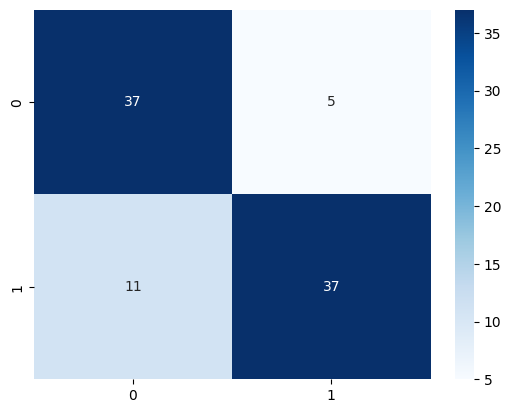

In [39]:
cm = confusion_matrix(
    y_test,
    y_pred
)
sns.heatmap(
    cm,
    annot = True,
    cmap = "Blues"
)

In [40]:
import pickle

In [41]:
with open ("random_forest.pkl","wb") as file:
    pickle.dump(model,file)

In [43]:
test_data = dict(zip(X_train.columns,
                    round(X_test.iloc[3],0)))
test_data

{'Area': 112808.0,
 'MajorAxisLength': 543.0,
 'MinorAxisLength': 267.0,
 'Eccentricity': 1.0,
 'ConvexArea': 116961.0,
 'Extent': 1.0,
 'Perimeter': 1390.0}

In [51]:
test_data = X.sample(1)

In [52]:
model.predict(test_data)

array([0])